#Important Python ML Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Create DF with CSV File

In [2]:
read_csv = pd.read_csv('penguins.csv')
df = pd.DataFrame(read_csv)

#Quick Overview of Data Frame

In [3]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [4]:
df.sample(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
100,Adelie,Biscoe,35.0,17.9,192.0,3725.0,female,2009
265,Gentoo,Biscoe,51.5,16.3,230.0,5500.0,male,2009
272,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,female,2009
107,Adelie,Biscoe,38.2,20.0,190.0,3900.0,male,2009
330,Chinstrap,Dream,42.5,17.3,187.0,3350.0,female,2009
88,Adelie,Dream,38.3,19.2,189.0,3950.0,male,2008
115,Adelie,Biscoe,42.7,18.3,196.0,4075.0,male,2009
252,Gentoo,Biscoe,48.5,15.0,219.0,4850.0,female,2009
336,Chinstrap,Dream,51.9,19.5,206.0,3950.0,male,2009
59,Adelie,Biscoe,37.6,19.1,194.0,3750.0,male,2008


In [5]:
df.tail()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009
343,Chinstrap,Dream,50.2,18.7,198.0,3775.0,female,2009


In [6]:
df.shape

(344, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


In [8]:
df.nunique()

,0
species,3
island,3
bill_length_mm,164
bill_depth_mm,80
flipper_length_mm,55
body_mass_g,94
sex,2
year,3


#Univariate Descriptive Statistics

In [9]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


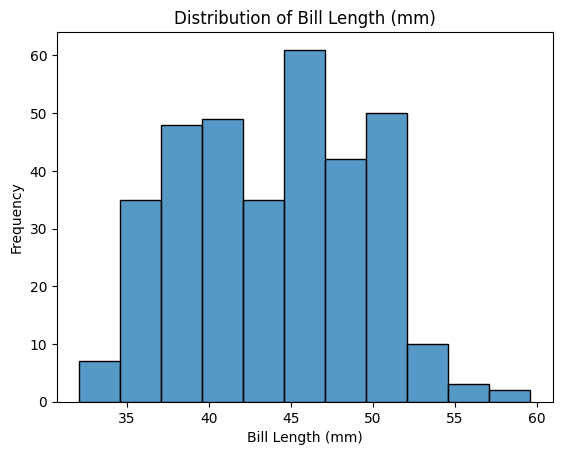

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram for 'bill_length_mm'
sns.histplot(df['bill_length_mm'], kde=False)  # kde=False removes the density line
plt.title("Distribution of Bill Length (mm)")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Frequency")
plt.show()

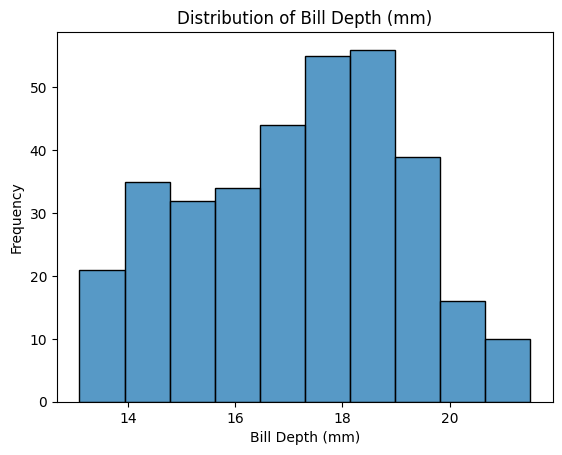

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram for 'bill_depth_mm'
sns.histplot(df['bill_depth_mm'], kde=False)  # kde=False removes the density line
plt.title("Distribution of Bill Depth (mm)")
plt.xlabel("Bill Depth (mm)")
plt.ylabel("Frequency")
plt.show()

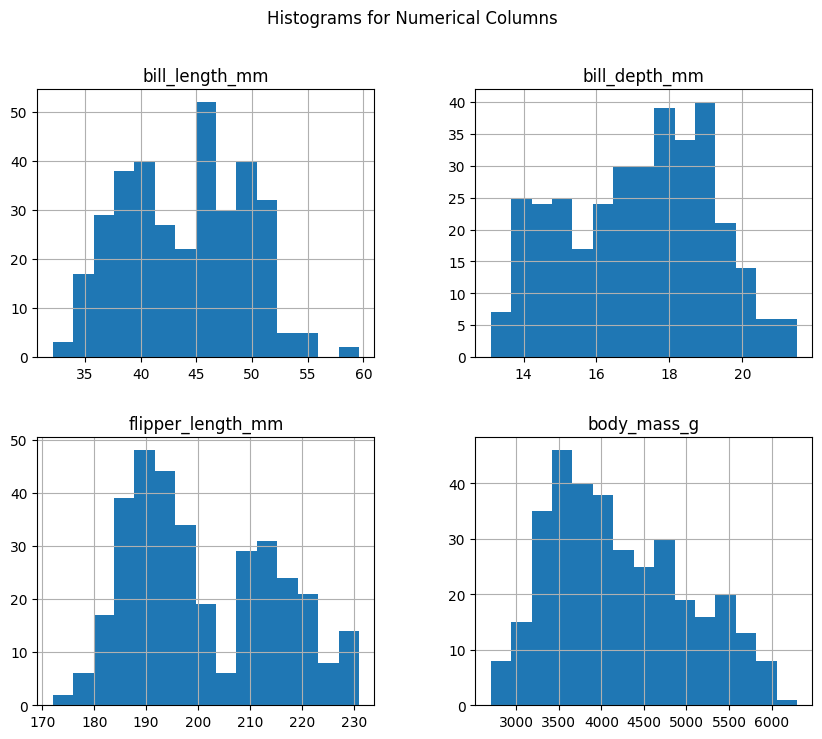

In [12]:
# Histograms
df_new = sns.load_dataset('penguins')

# Define numerical_cols
numerical_cols = df_new.select_dtypes(include=['number']) # Selects numerical columns

numerical_cols.hist(figsize=(10, 8), bins=15)
plt.suptitle('Histograms for Numerical Columns')
plt.show()

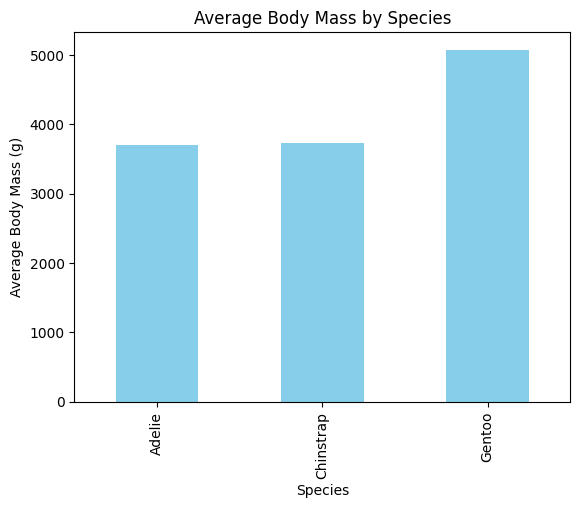

In [13]:
import seaborn as sns
df_new = sns.load_dataset('penguins')

# Strip any leading/trailing whitespace from the column names
df_new.columns = df_new.columns.str.strip()

df_new.groupby('species')['body_mass_g'].mean().plot(kind='bar', color='skyblue')

plt.title("Average Body Mass by Species")
plt.xlabel("Species")
plt.ylabel("Average Body Mass (g)")
plt.show()

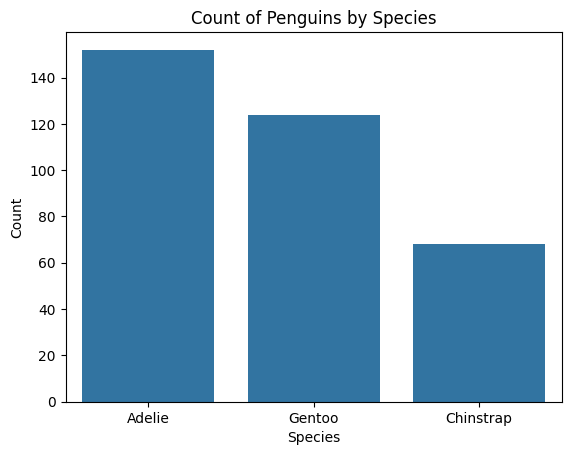

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn
# Assuming df has the data you want to plot
sns.countplot(x='species', data=df) # Use df instead of df_new
plt.title("Count of Penguins by Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

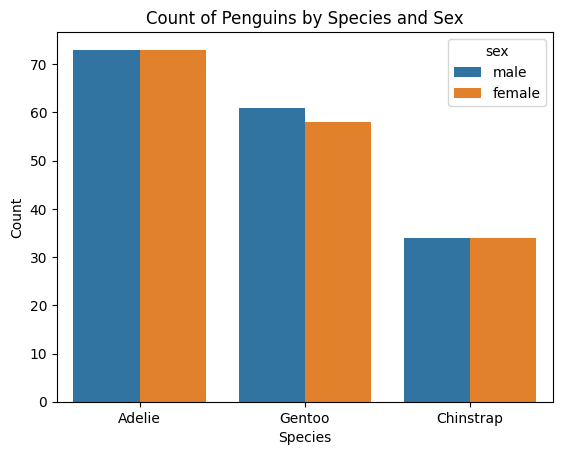

In [15]:
import matplotlib.pyplot as plt
sns.countplot(x='species', hue='sex', data=df)
plt.title("Count of Penguins by Species and Sex")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

In [16]:
# Create a cross-tabulation
cross_tab = pd.crosstab(df['species'], df['island'])

# Display the cross-tabulation
print(cross_tab)

island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0


In [17]:
# Create a cross-tabulation
cross_tab = pd.crosstab(df['species'], df['sex'])

# Display the cross-tabulation
print(cross_tab)

sex        female  male
species                
Adelie         73    73
Chinstrap      34    34
Gentoo         58    61


In [18]:
# Create a cross-tabulation
cross_tab = pd.crosstab(df['island'], df['sex'])

# Display the cross-tabulation
print(cross_tab)

sex        female  male
island                 
Biscoe         80    83
Dream          61    62
Torgersen      24    23


In [19]:
df['bill_length_mm'].value_counts() # Use square brackets to access the column 'bill_length_mm

,count
bill_length_mm,
41.1,7
45.2,6
39.6,5
37.8,5
46.2,5
...,...
51.0,1
53.5,1
51.4,1


In [20]:
df['species'].value_counts() # Use square brackets to access the column 'species' and parenthesis to call the function 'value_counts'

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


In [21]:
df['year'].value_counts()

,count
year,
2009,120
2008,114
2007,110


In [22]:
df['island'].value_counts()

,count
island,
Biscoe,168
Dream,124
Torgersen,52


In [23]:
df['sex'].value_counts()

,count
sex,
male,168
female,165


In [24]:
# Convert 'bill_length_mm' to numeric, coercing errors to NaN
df['bill_length_mm'] = pd.to_numeric(df['bill_length_mm'], errors='coerce')

# Check for any conversion issues
print("Missing values after conversion:", df['bill_length_mm'].isnull().sum())

# Optionally, drop rows with NaN values (if you don't want to include them in the analysis)
df_clean = df.dropna(subset=['bill_length_mm'])

# Create bins for 'bill_length_mm' and count values in each bin
bins = pd.cut(df_clean['bill_length_mm'], bins=10)
counts = bins.value_counts()

# Print the bin ranges and corresponding counts
print(counts)

Missing values after conversion: 2
bill_length_mm
(48.6, 51.35]      60
(45.85, 48.6]      56
(37.6, 40.35]      54
(40.35, 43.1]      49
(43.1, 45.85]      48
(34.85, 37.6]      43
(51.35, 54.1]      16
(32.072, 34.85]     9
(54.1, 56.85]       5
(56.85, 59.6]       2
Name: count, dtype: int64


##Missing Values by Case

In [25]:
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11
year,0


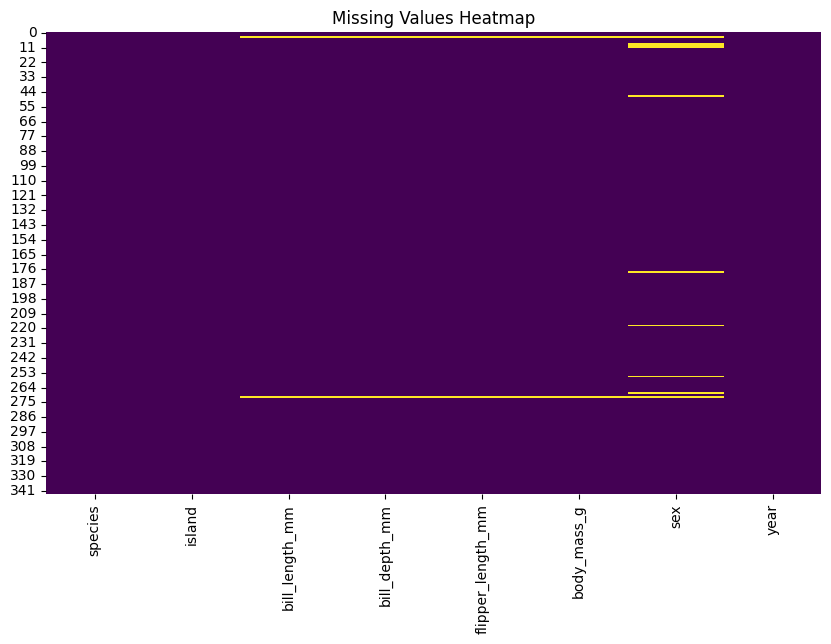

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize missing values with a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

##Outlier Detection

In [27]:
# Check for missing values in the dataset
missing_values = df.isnull().sum()
print(f"Missing values in the dataset:\n{missing_values}")

# Drop rows with missing values before calculating Z-scores
df_clean = df.dropna()

# Import the scipy.stats module
from scipy import stats

# Recalculate Z-scores after cleaning the data
z_scores_clean = np.abs(stats.zscore(df_clean.select_dtypes(include=['float64', 'int64'])))

# Detect outliers using a threshold of 2
outliers_clean_test = (z_scores_clean > 2).sum()

# Output the number of outliers detected with the new threshold
print(f"Outliers detected (threshold=0.5):\n{outliers_clean_test}")

Missing values in the dataset:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64
Outliers detected (threshold=0.5):
34


In [28]:
# IQR outliers detection
Q1 = df.select_dtypes(include=['float64', 'int64']).quantile(0.25) # Select only numerical columns for IQR calculation
Q3 = df.select_dtypes(include=['float64', 'int64']).quantile(0.75)
IQR = Q3 - Q1

# Use the same selection of numerical columns when comparing with the IQR
numerical_df = df.select_dtypes(include=['float64', 'int64'])
outliers = ((numerical_df < (Q1 - 1.5 * IQR)) | (numerical_df > (Q3 + 1.5 * IQR))).sum()

print(f"Outliers detected based on IQR method:\n{outliers}")

Outliers detected based on IQR method:
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
year                 0
dtype: int64


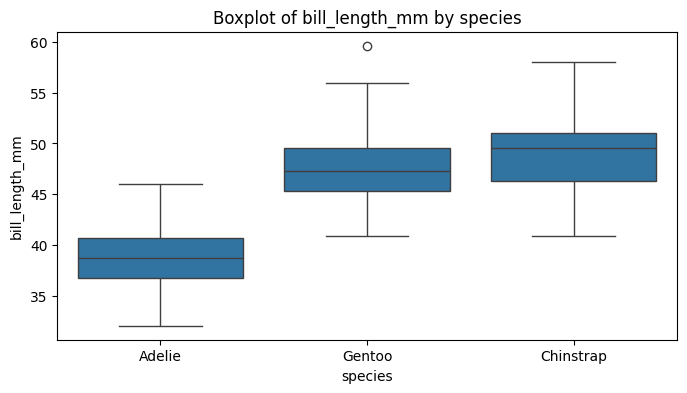

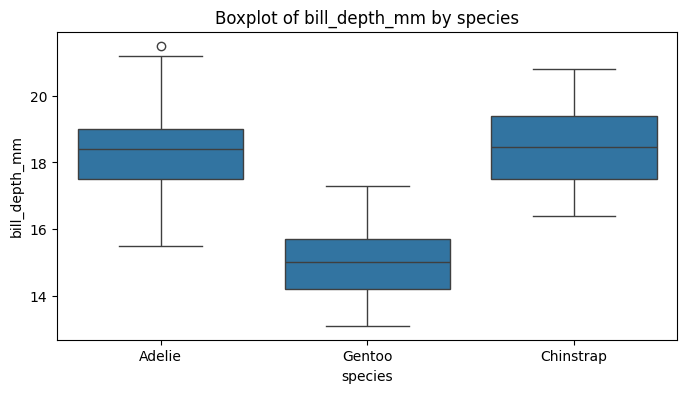

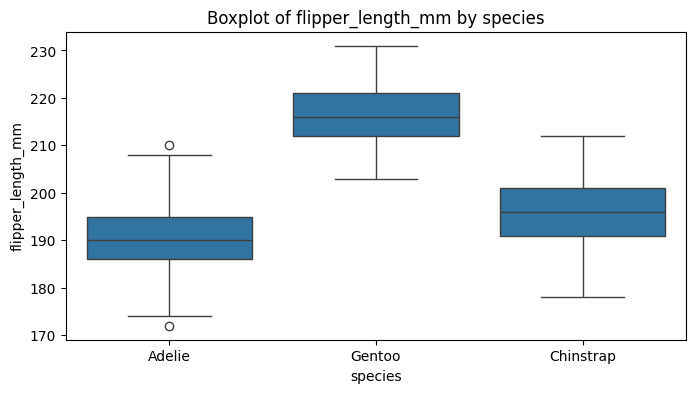

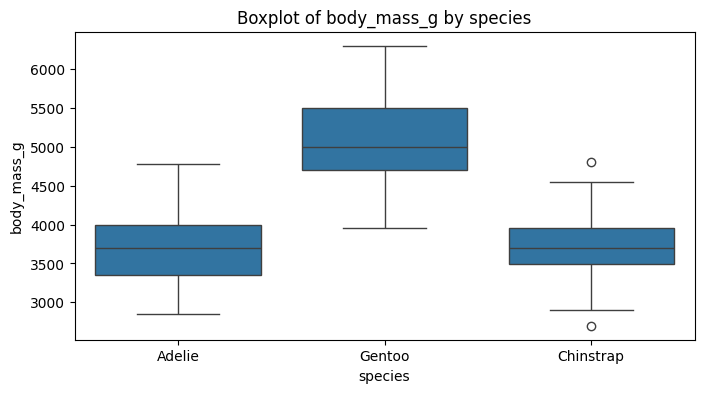

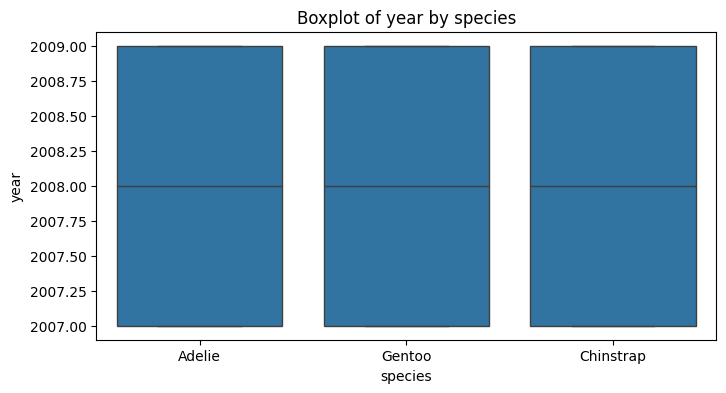

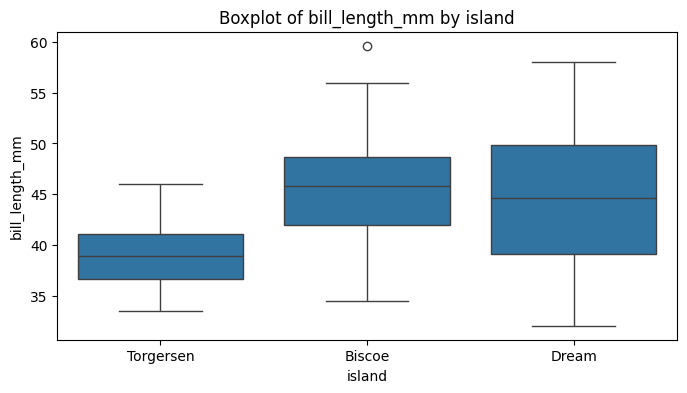

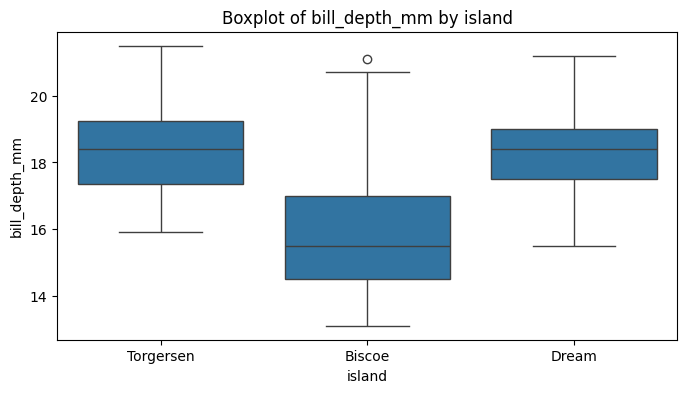

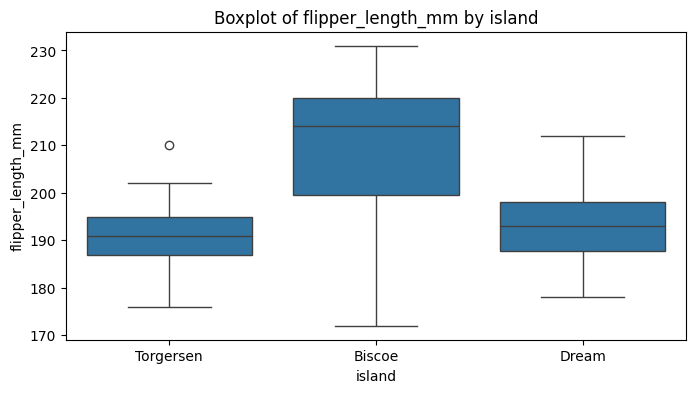

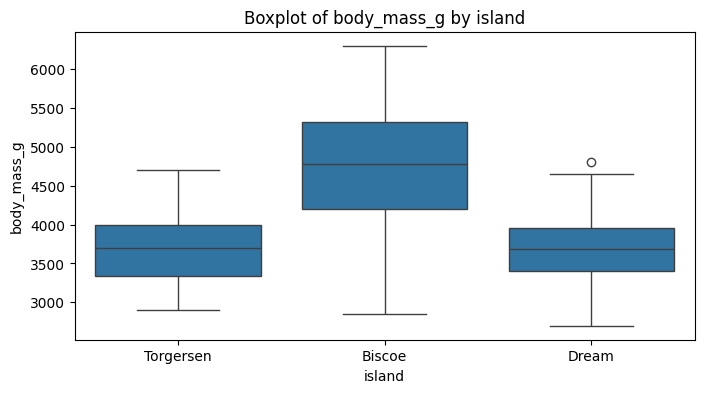

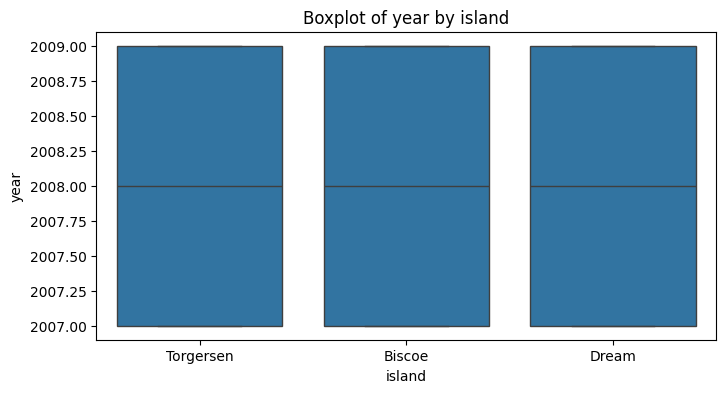

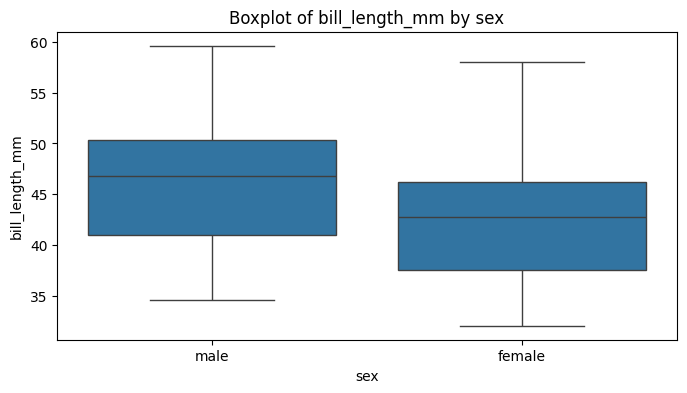

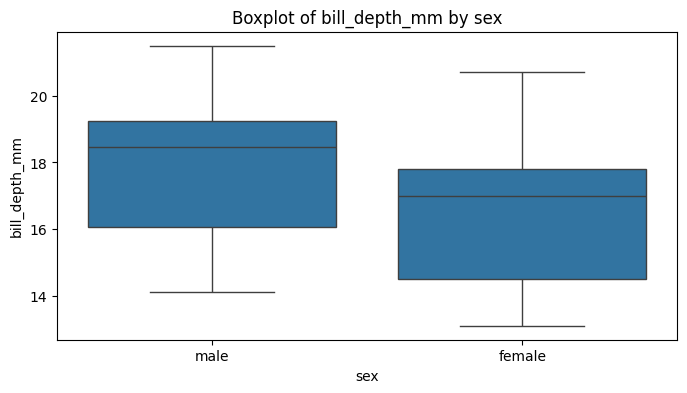

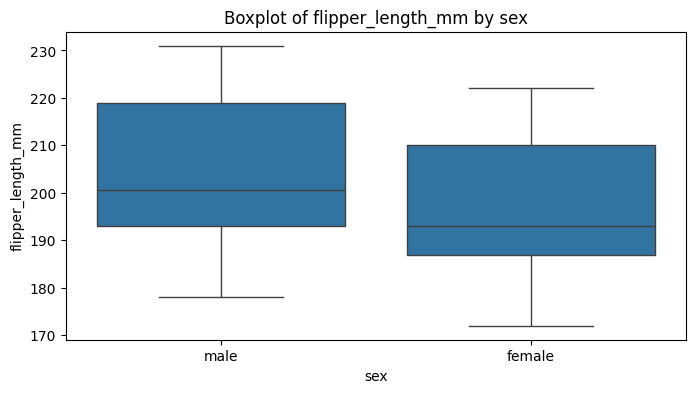

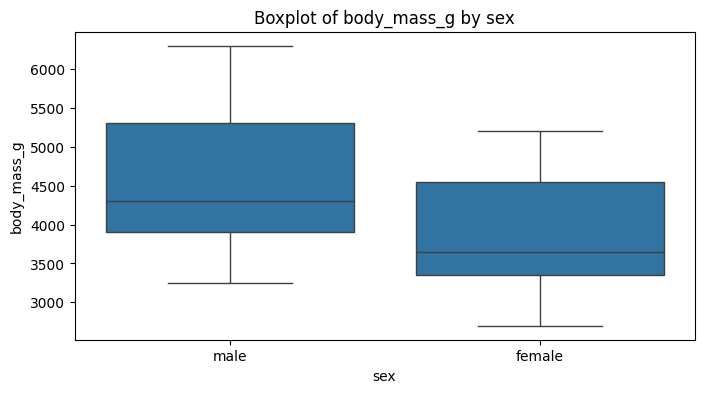

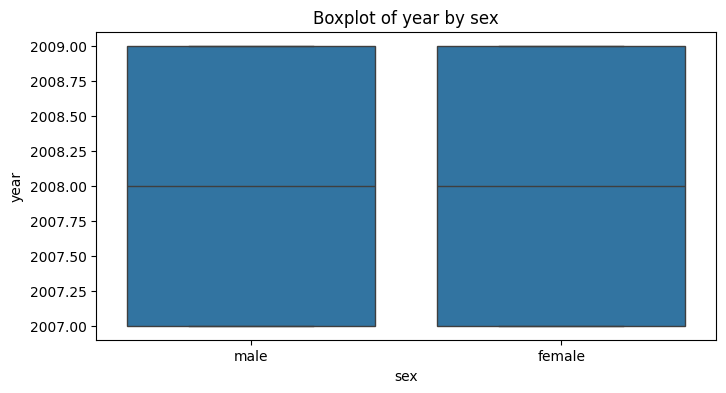

In [29]:
categorical_cols = df.select_dtypes(include=['object'])
# Define numerical_cols
numerical_cols = df.select_dtypes(include=['float64', 'int64'])

for col in categorical_cols.columns:
    for num_col in numerical_cols.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[col], y=df[num_col])
        plt.title(f'Boxplot of {num_col} by {col}')
        plt.show()

##Normality (Kurtosis & Skewness)

In [30]:
!pip install scipy
import pandas as pd
from scipy.stats import skew, kurtosis # Import both skew and kurtosis functions

# Select only numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64'])

# Calculate skewness for each numerical column
skewness = numerical_cols.apply(lambda x: skew(x.dropna()))

# Calculate kurtosis for each numerical column
kurt = numerical_cols.apply(lambda x: kurtosis(x.dropna()))

# Combine skewness and kurtosis into a single DataFrame
skew_kurt_df = pd.DataFrame({
    'Skewness': skewness,
    'Kurtosis': kurt
})

# Display the result
print(skew_kurt_df)

#Explanation:
#select_dtypes(include=['float64', 'int64']): Filters the DataFrame to only include numerical columns.
#apply(lambda x: skew(x.dropna())): Applies the skew function to each numerical column, ignoring missing values.
#apply(lambda x: kurtosis(x.dropna())): Applies the kurtosis function to each numerical column, again ignoring missing values.
#pd.DataFrame({...}): Combines skewness and kurtosis into a DataFrame for easy viewing.

                   Skewness  Kurtosis
bill_length_mm     0.052885 -0.880765
bill_depth_mm     -0.142835 -0.911155
flipper_length_mm  0.344164 -0.987434
body_mass_g        0.468264 -0.726243
year              -0.053493 -1.500543


#Bivarariate Descriptive Statistics

##Correlatation

In [31]:
# Calculate correlation matrix for numerical columns only
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Display correlation matrix
print(correlation_matrix)

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.235053           0.656181   
bill_depth_mm           -0.235053       1.000000          -0.583851   
flipper_length_mm        0.656181      -0.583851           1.000000   
body_mass_g              0.595110      -0.471916           0.871202   
year                     0.054545      -0.060354           0.169675   

                   body_mass_g      year  
bill_length_mm        0.595110  0.054545  
bill_depth_mm        -0.471916 -0.060354  
flipper_length_mm     0.871202  0.169675  
body_mass_g           1.000000  0.042209  
year                  0.042209  1.000000  


##Individual Scatterplots

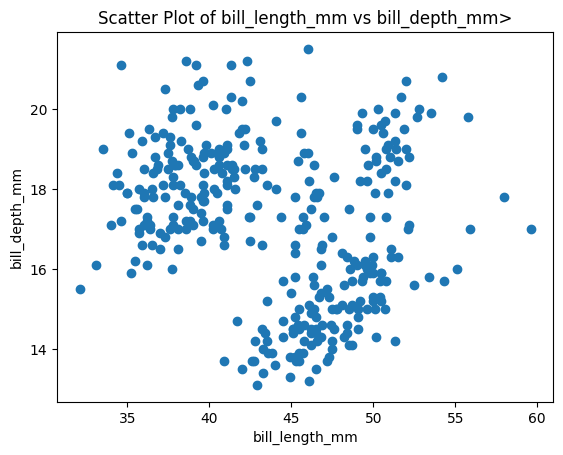

In [32]:
import matplotlib.pyplot as plt

# Create a scatter plot
# Replace 'variable1' and 'variable2' with actual column names from your DataFrame
plt.scatter(df['bill_length_mm'], df['bill_depth_mm'])

# Add labels and title
plt.xlabel('bill_length_mm')
plt.ylabel('bill_depth_mm')
plt.title('Scatter Plot of bill_length_mm vs bill_depth_mm>')

# Show plot
plt.show()

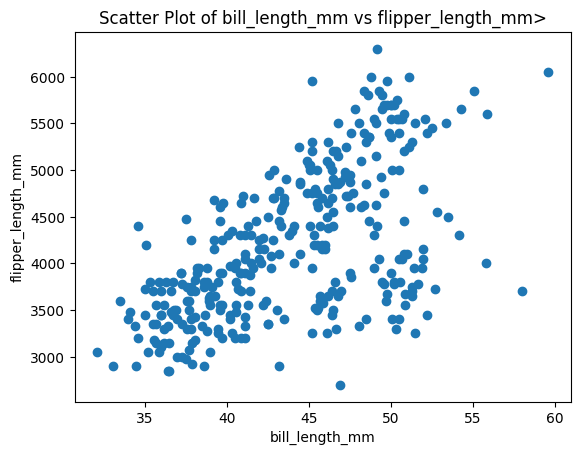

In [33]:
import matplotlib.pyplot as plt

# Create a scatter plot
# Replace 'variable1' and 'variable2' with actual column names from your DataFrame
plt.scatter(df['bill_length_mm'], df['body_mass_g'])

# Add labels and title
plt.xlabel('bill_length_mm')
plt.ylabel('flipper_length_mm')
plt.title('Scatter Plot of bill_length_mm vs flipper_length_mm>')

# Show plot
plt.show()

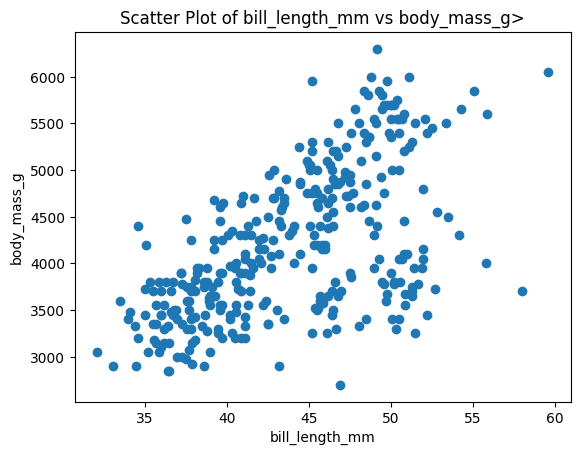

In [34]:
import matplotlib.pyplot as plt

# Create a scatter plot
# Replace 'variable1' and 'variable2' with actual column names from your DataFrame
plt.scatter(df['bill_length_mm'], df['body_mass_g'])

# Add labels and title
plt.xlabel('bill_length_mm')
plt.ylabel('body_mass_g')
plt.title('Scatter Plot of bill_length_mm vs body_mass_g>')

# Show plot
plt.show()

##All Pairwise Scatterplots

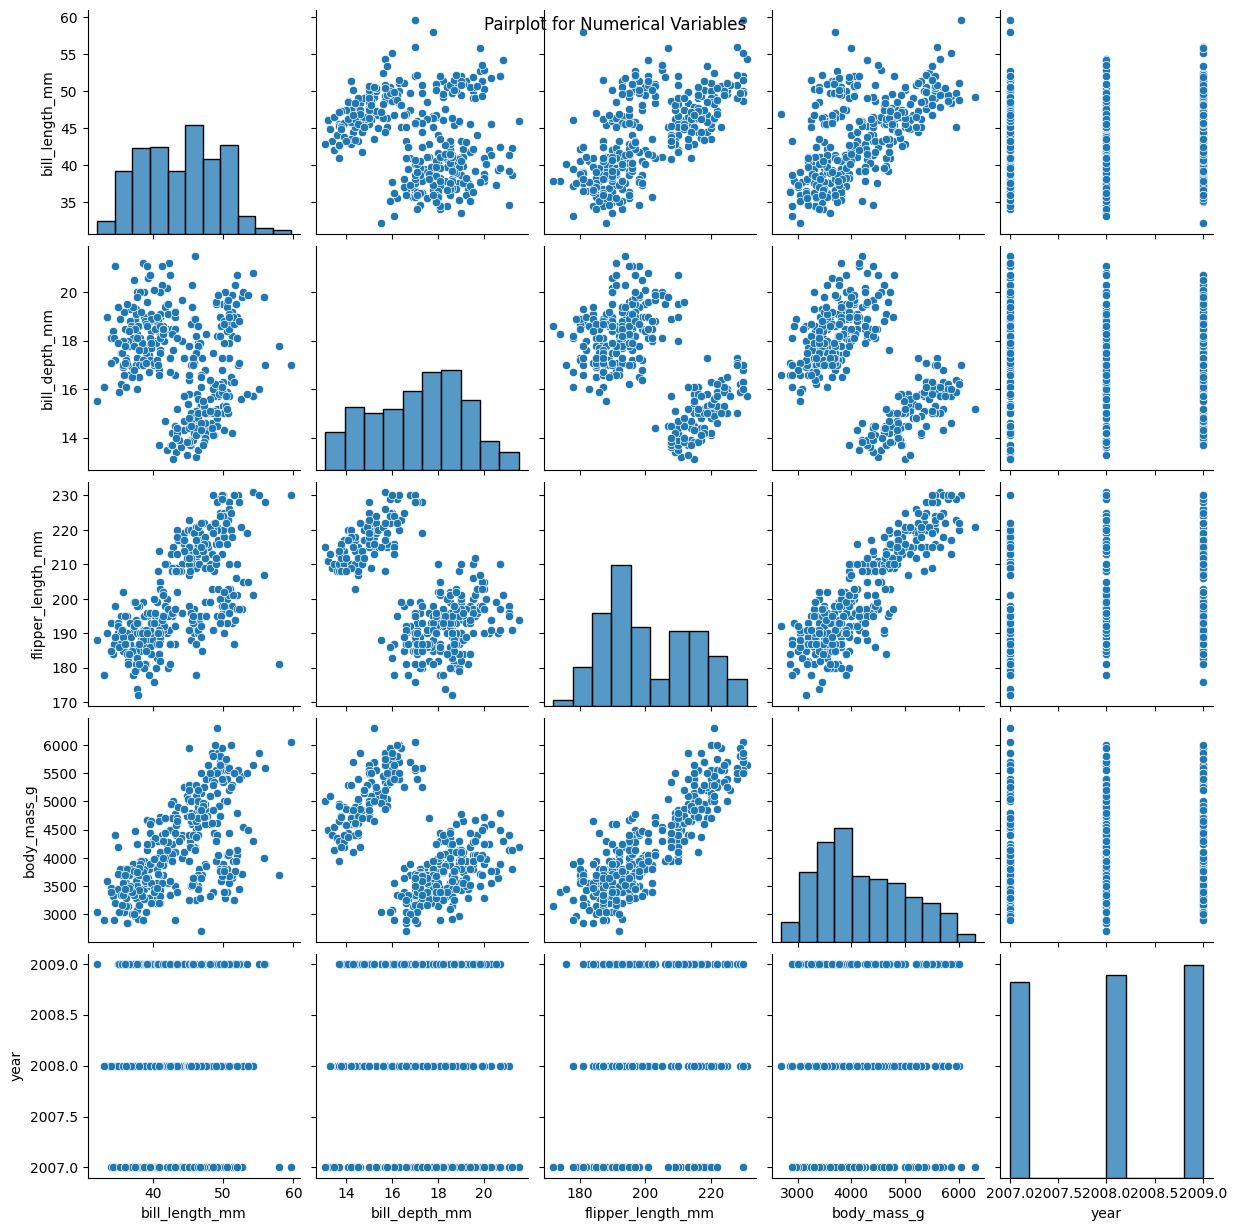

In [35]:
sns.pairplot(df)
plt.suptitle('Pairplot for Numerical Variables')
plt.show()

##All Pairwise Correlations

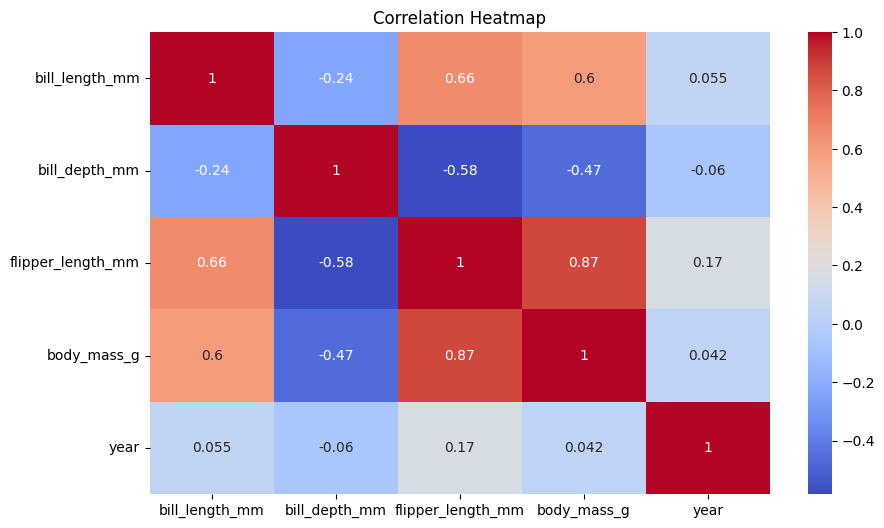

In [36]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#Pandas Profiling
The pandas_profiling library provides an easy and comprehensive report for data exploration in one line of code.

In [37]:
!pip install pandas-profiling
# pandas-profiling has been renamed to ydata-profiling
!pip install ydata-profiling


  Using cached visions-0.7.4-py3-none-any.whl.metadata (5.9 kB)
Using cached visions-0.7.4-py3-none-any.whl (102 kB)
  Attempting uninstall: visions
    Found existing installation: visions 0.8.1
    Uninstalling visions-0.8.1:
      Successfully uninstalled visions-0.8.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.16.1 requires visions[type_image_path]<0.8.2,>=0.7.5, but you have visions 0.7.4 which is incompatible.
  Using cached visions-0.8.1-py3-none-any.whl.metadata (11 kB)
Using cached visions-0.8.1-py3-none-any.whl (105 kB)
  Attempting uninstall: visions
    Found existing installation: visions 0.7.4
    Uninstalling visions-0.7.4:
      Successfully uninstalled visions-0.7.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following depen

In [38]:
import pandas as pd
#from pandas_profiling import ProfileReport # This has been deprecated
from ydata_profiling import ProfileReport # Use this instead

# Load your DataFrame
# Assuming 'df' is your DataFrame

# Create a profile report
profile = ProfileReport(df, title="Pandas Profiling Report", explorative=True)

# Display the report
profile.to_notebook_iframe()  # If using Jupyter Notebook

# To save the report as an HTML file:
profile.to_file("data_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 44.11it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

##What It Does:
The pandas_profiling library generates a detailed report including:

*   Overview: Data types, missing values, memory usage.
*   Descriptive Statistics: Mean, standard deviation, min/max, percentiles.
*   Missing Values: Visual representation of missing data.
*   Correlation: Pearson, Spearman, Kendall correlations between variables.
*   Outliers: Detection based on Z-scores and IQR.
*   Distributions: Histograms and KDE plots for each variable.
*   Interactions: Pairwise interactions between variables.
*   Skewness and Kurtosis: Automatically included for numerical columns.